# Activation Maximization for Feature Visualization in InceptionV1

This notebook demonstrates **activation maximization** — a classic interpretability technique used to understand what individual channels (feature maps) in a deep convolutional neural network have learned to detect. We use the pre-trained **InceptionV1 (GoogLeNet)** model and visualize the preferred patterns for the first 10 channels of the `mixed4a` layer.

## Overview of the Technique
- We treat the input image as a **learnable parameter**.
- We optimize its pixel values via **gradient ascent** to **maximize** the average activation of a chosen channel.
- The resulting optimized image reveals the visual pattern that strongly excites that channel.



In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

 ### 1. Load Pre-trained InceptionV1 Model



In [2]:
# ───────────────────────────────────────────────
# 1. Load pretrained InceptionV1 (GoogLeNet)
# ───────────────────────────────────────────────
model = models.googlenet(weights='GoogLeNet_Weights.IMAGENET1K_V1').eval()

# Important: put on device & disable grad for model params
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
for param in model.parameters():
    param.requires_grad_(False)

### 2. Hook to Capture Activations from mixed4a



In [3]:
# ───────────────────────────────────────────────
# 2. Helper to get activation of mixed4a[:, channel, :, :]
# ───────────────────────────────────────────────
activations = {}

def get_activation(name):
    def hook(module, input, output):
        activations[name] = output
    return hook

# mixed4a is an Inception block — hook its output
model.inception4a.register_forward_hook(get_activation('mixed4a'))

### 3. Normalization and Deprocessing Functions



In [11]:
# ───────────────────────────────────────────────
# 3. Preprocessing / deprocessing (updated)
# ───────────────────────────────────────────────
# Only normalization — input is already a torch tensor [C,H,W] in [0,1]
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

def deprocess(tensor):
    """Undo normalization + clip to [0,1] for display"""
    mean = torch.tensor([0.485, 0.456, 0.406], device=tensor.device).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=tensor.device).view(3,1,1)
    
    # Key fix: detach before any further operations that lead to .numpy()
    img = tensor.detach().clone().squeeze(0) * std + mean
    img = img.clamp(0, 1)
    
    return img.permute(1, 2, 0).cpu().numpy()   # Now safe

### 4. Activation Maximization Core Function



In [12]:
# ───────────────────────────────────────────────
# 4. Activation maximization function (fixed)
# ───────────────────────────────────────────────
def activation_maximization(channel_idx, steps=800, lr=0.05, tv_weight=1e-4):
    # Learnable image tensor: [1, 3, 224, 224], values in [0,1]
    img = torch.rand(1, 3, 224, 224, requires_grad=True, device=device)
    
    optimizer = torch.optim.Adam([img], lr=lr)
    
    for step in range(steps):
        optimizer.zero_grad()
        
        # Normalize the current img tensor (already in correct format)
        norm_img = normalize(img)                     # ← key fix: only normalize
        
        # Forward pass
        _ = model(norm_img)
        
        # Get activation of chosen channel (mean over spatial dims for scalar)
        act = activations['mixed4a'][0, channel_idx].mean()
        
        # Loss = -activation (to maximize)
        loss = -act
        
        # Optional total variation (smoothness) regularizer
        if tv_weight > 0:
            diff_h = torch.abs(img[:,:,1:,:] - img[:,:,:-1,:]).sum()
            diff_w = torch.abs(img[:,:,:,1:] - img[:,:,:,:-1]).sum()
            tv = diff_h + diff_w
            loss += tv_weight * tv
        
        loss.backward()
        optimizer.step()
        
        # Keep values reasonable
        with torch.no_grad():
            img.clamp_(0, 1)
        
        if step % 200 == 0:
            print(f"Channel {channel_idx} | Step {step} | Act {act.item():.4f}")
    
    return deprocess(img)

### 5. Visualize Results for First 10 Channels




Optimizing mixed4a channel 0
Channel 0 | Step 0 | Act 0.0000
Channel 0 | Step 200 | Act 10.8428
Channel 0 | Step 400 | Act 11.4762
Channel 0 | Step 600 | Act 11.7347
Channel 0 | Step 800 | Act 11.8929
Channel 0 | Step 1000 | Act 11.9783

Optimizing mixed4a channel 1
Channel 1 | Step 0 | Act 0.0000
Channel 1 | Step 200 | Act 21.6757
Channel 1 | Step 400 | Act 22.1923
Channel 1 | Step 600 | Act 22.4582
Channel 1 | Step 800 | Act 22.6189
Channel 1 | Step 1000 | Act 22.7751

Optimizing mixed4a channel 2
Channel 2 | Step 0 | Act 0.0000
Channel 2 | Step 200 | Act 0.0000
Channel 2 | Step 400 | Act 0.0000
Channel 2 | Step 600 | Act 0.0000
Channel 2 | Step 800 | Act 0.0000
Channel 2 | Step 1000 | Act 0.0000

Optimizing mixed4a channel 3
Channel 3 | Step 0 | Act 0.0000
Channel 3 | Step 200 | Act 17.1355
Channel 3 | Step 400 | Act 17.8535
Channel 3 | Step 600 | Act 18.1535
Channel 3 | Step 800 | Act 18.3589
Channel 3 | Step 1000 | Act 18.5013

Optimizing mixed4a channel 4
Channel 4 | Step 0 | Ac

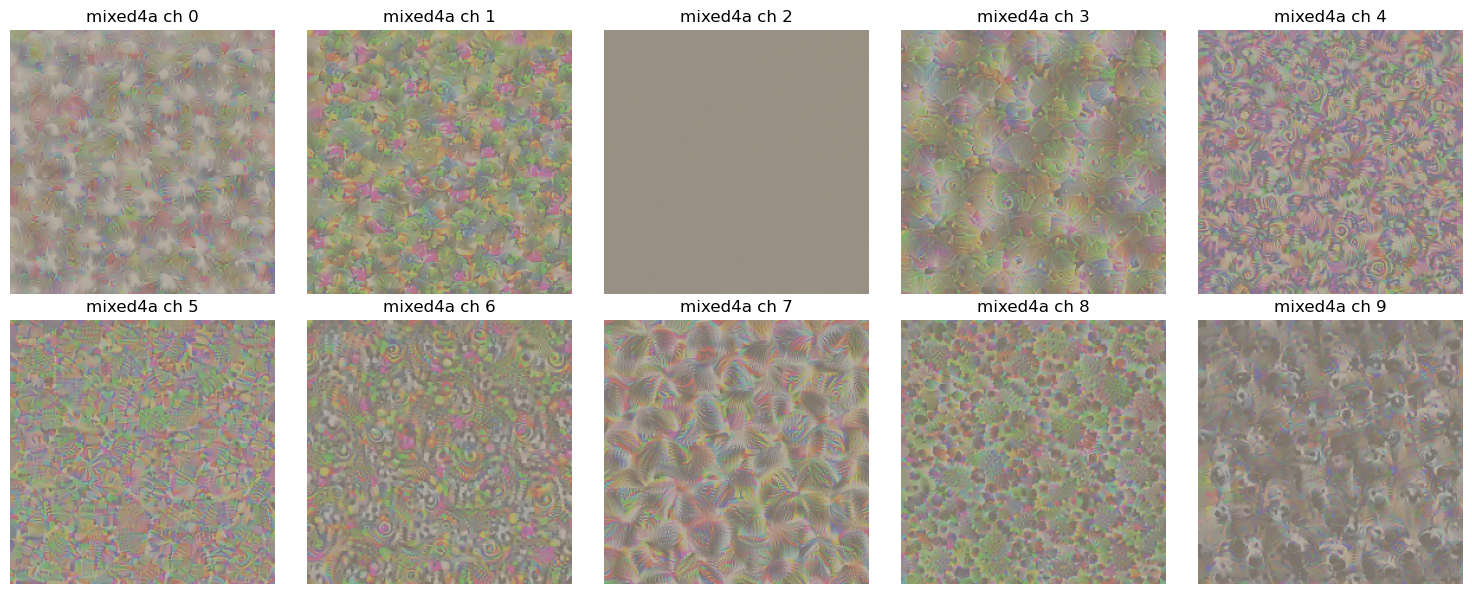

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for ch in range(10):
    print(f"\nOptimizing mixed4a channel {ch}")
    vis_img = activation_maximization(ch, steps=1200, lr=0.1, tv_weight=2e-4)
    
    axes[ch].imshow(vis_img)
    axes[ch].set_title(f"mixed4a ch {ch}")
    axes[ch].axis('off')

plt.tight_layout()
plt.show()